In [1]:

# Environment and library configuration
# Run this cell first.
#
# This cell checks whether the required Python packages are available.
# If a package is missing (for example rasterio), it will be installed
# into the current notebook environment before the workflow imports it.
# It is recommended to use a higher-resource (Medium 16 CPU, 32G RAM for example) runtime.

import os
import sys
import subprocess
import importlib.util
import re
import math
import calendar
from pathlib import Path
from datetime import date, timedelta
from collections import defaultdict
from contextlib import contextmanager

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "rasterio": "rasterio",
    "joblib": "joblib",
    "tqdm": "tqdm",
    "matplotlib": "matplotlib",
}

missing = [pkg_name for module_name, pkg_name in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(module_name) is None]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
    except subprocess.CalledProcessError as e:
        raise RuntimeError(
            "Automatic package installation failed. "
            "Please install the missing packages manually in your environment, "
            "for example with: pip install " + " ".join(missing)
        ) from e
else:
    print("All required packages are already available.")

# Third-party imports
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from rasterio.crs import CRS
from rasterio.transform import Affine, array_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# Optional environment settings for faster raster I/O where supported
os.environ.setdefault("GDAL_NUM_THREADS", "ALL_CPUS")
os.environ.setdefault("NUM_THREADS", "ALL_CPUS")

# -----------------------------------------------------------------------------
# Repository-aware paths and path overrides
# -----------------------------------------------------------------------------
# If automatic path detection does not match your local repository layout,
# set MANUAL_MODIS_DIR and/or MANUAL_ANALYSIS_READY_DIR to absolute paths.
MANUAL_MODIS_DIR = None
MANUAL_ANALYSIS_READY_DIR = None
SEARCH_RECURSIVELY_FOR_MODIS = True

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

# -----------------------------------------------------------------------------
# Processing parameters
# -----------------------------------------------------------------------------
PIXEL_SIZE_M = 500
TARGET_GRID_SIZE_M = 3000
AGG_FACTOR = TARGET_GRID_SIZE_M // PIXEL_SIZE_M  # 500 m -> 3 km

ROLLING_WINDOW = 10
CLOUD_DOMINANCE_THRESHOLD = 0.8

FREEZE_THRESHOLD = 0.2
BREAK_THRESHOLD = 0.2

# Freeze-up search window relative to the hydrological year convention
FREEZE_SEARCH_START = -70
FREEZE_SEARCH_END = 180

# Break-up search settings
BREAKUP_SEARCH_START = (2, 2)   # first day eligible for break-up search: Feb 2 in year Y
BREAK_SEARCH_START = 100
BREAK_SEARCH_END = 300

# Winter peak window used before break-up detection
WINTER_PEAK_START = (12, 1)     # Dec 1 in year Y-1
WINTER_PEAK_END = (2, 1)        # Feb 1 in year Y

# Lead period before 1 October to allow negative DOHY freeze-up values
PRE_LEAD_DAYS = 70

# Plausible output ranges used for post-checking
FREEZE_RANGE = (-70, 140)
BREAK_RANGE = (120, 310)

# Output and execution settings
NODATA_FLOAT = -9999.0
NODATA_INT16 = -32768
NODATA_UINT16 = 0

OVERWRITE_OUTPUTS = False
N_JOBS = -1

print("Notebook working directory:", NOTEBOOK_DIR)
print("Project directory guess:", PROJECT_DIR)
print("Default overwrite mode:", OVERWRITE_OUTPUTS)
print("Default parallel jobs:", N_JOBS)


All required packages are already available.
Notebook working directory: /home/jovyan/FinalProject
Project directory guess: /home/jovyan/FinalProject
Default overwrite mode: False
Default parallel jobs: -1


# SE2 data processing: MODIS river ice to analysis-ready ice phenology

This notebook converts daily mapped MODIS river-ice rasters in `../raw_data/MODIS_image` into annual **analysis-ready ice phenology** products in `../analysis_ready/ice_phenology`.

The workflow follows the SE2 structure:
1. **Data ingestion**
2. **Quality control**
3. **Harmonization**
4. **Variable derivation**
5. **Export**


## Overview

### Input data
**Raw data:** daily MODIS river-ice classification rasters stored in `../raw_data/MODIS_image`.

Expected encoding in the source rasters:
- `255` = ice
- `0` = water
- `10` = cloud
- `NaN` or raster nodata = invalid / missing observation

### Analysis-ready outputs
This notebook produces annual ice phenology rasters in `../analysis_ready/ice_phenology`:

- `freezeup_DOHY/freezeup_DOHY_<year>.tif`
- `breakup_DOHY/breakup_DOHY_<year>.tif`
- `ice_duration_DAY/ice_duration_DAY_<year>.tif`

Where:
- **DOHY** = day of hydrological year, with **1 = 1 October**
- Freeze-up can be negative because the search window is extended **70 days before 1 October**
- Duration is exported in **days**

### Intermediate products
To keep the workflow transparent and reproducible, the notebook also writes harmonized daily 3 km rasters to:
- `../analysis_ready/RIC`
- `../analysis_ready/WC`

These intermediate products are generated from the raw MODIS rasters and then used to derive the final annual phenology layers.

### Path handling
The notebook first tries the standard repository layout, where `raw_data` and `analysis_ready` are siblings of the project directory. To make the workflow more robust in Jupyter environments, it also checks several nearby candidate locations and can fall back to a recursive search for a folder named `MODIS_image` that already contains GeoTIFF files.

If your local structure is different, you can set absolute paths manually in the first code cell:
- `MANUAL_MODIS_DIR`
- `MANUAL_ANALYSIS_READY_DIR`

### Modelling compatibility
The outputs are GeoTIFF rasters compatible with standard geospatial workflows in Python, R, GDAL, QGIS, ArcGIS, and downstream ice-phenology analysis pipelines.

### Processing logic in plain language
1. Read daily raw MODIS classification rasters.
2. Aggregate 500 m classes to a 3 km grid and compute daily proportions of river ice cover (RIC), water cover (WC), and cloud cover (CC).
3. Apply temporal smoothing **within each hydrological year only** to avoid smoothing across adjacent winter seasons.
4. Reallocate cloud fraction using rule-based post-classification.
5. Build annual RIC stacks and derive freeze-up date, break-up date, and ice duration.
6. Export the final analysis-ready rasters.



In [2]:
# Utility functions shared by both processing stages

DATE_PATTERN = re.compile(r".*?(\d{8}).*?")


def parse_date_from_name(path_like):
    """
    Extract a date from a filename that contains an 8-digit YYYYMMDD string.
    Returns a datetime.date object, or None if parsing fails.
    """
    path_like = Path(path_like)
    match = DATE_PATTERN.match(path_like.name)
    if not match:
        return None
    ymd = match.group(1)
    try:
        return date(int(ymd[:4]), int(ymd[4:6]), int(ymd[6:8]))
    except Exception:
        return None


def hydrological_year(d):
    """
    Hydrological year label:
    - Oct-Dec 2000 -> 2001
    - Jan-Sep 2001 -> 2001
    """
    return d.year + 1 if d.month >= 10 else d.year


def hy_start(hy_label):
    """Hydrological year starts on 1 October of the previous calendar year."""
    return date(hy_label - 1, 10, 1)


def dohy_for_date_in_hy(d, hy_label):
    """Day of hydrological year (1 = Oct 1). Negative values are allowed."""
    return (d - hy_start(hy_label)).days + 1


def daterange(d0, d1):
    cur = d0
    one_day = timedelta(days=1)
    while cur <= d1:
        yield cur
        cur += one_day


def list_tifs(folder, recursive=False):
    folder = Path(folder)
    patterns = ("*.tif", "*.TIF", "*.tiff", "*.TIFF")
    files = []
    for pattern in patterns:
        iterator = folder.rglob(pattern) if recursive else folder.glob(pattern)
        files.extend(iterator)
    return sorted({Path(f) for f in files})


def unique_paths(paths):
    out = []
    seen = set()
    for p in paths:
        p = Path(p).resolve()
        if p not in seen:
            seen.add(p)
            out.append(p)
    return out


def candidate_modis_dirs():
    return unique_paths([
        PROJECT_DIR.parent / "raw_data" / "MODIS_image",
        PROJECT_DIR / "raw_data" / "MODIS_image",
        NOTEBOOK_DIR.parent / "raw_data" / "MODIS_image",
        NOTEBOOK_DIR / "raw_data" / "MODIS_image",
        Path.home() / "raw_data" / "MODIS_image",
    ])


def resolve_modis_dir(manual_dir=None, recursive_search=SEARCH_RECURSIVELY_FOR_MODIS):
    checked = []

    if manual_dir:
        p = Path(manual_dir).expanduser().resolve()
        checked.append(p)
        tif_count = len(list_tifs(p, recursive=False)) if p.exists() else 0
        if p.exists() and tif_count > 0:
            return p, checked
        raise RuntimeError(
            f"MANUAL_MODIS_DIR exists but contains no GeoTIFF files: {p}"
        )

    for p in candidate_modis_dirs():
        checked.append(p)
        if p.exists() and p.is_dir():
            tif_count = len(list_tifs(p, recursive=False))
            if tif_count > 0:
                return p, checked

    if recursive_search:
        search_roots = unique_paths([PROJECT_DIR, PROJECT_DIR.parent, NOTEBOOK_DIR, Path.home()])
        for root in search_roots:
            if not root.exists():
                continue
            try:
                for p in root.rglob("MODIS_image"):
                    p = Path(p).resolve()
                    if p in checked or not p.is_dir():
                        continue
                    checked.append(p)
                    tif_count = len(list_tifs(p, recursive=False))
                    if tif_count > 0:
                        return p, checked
            except Exception:
                continue

    checked_txt = "\n".join(f"- {p}" for p in checked)
    raise RuntimeError(
        "No GeoTIFF files were found in the MODIS input directory.\n"
        "Checked the following candidate directories:\n"
        f"{checked_txt}\n\n"
        "If your data are stored elsewhere, set MANUAL_MODIS_DIR in the first code cell."
    )


def resolve_analysis_ready_dir(modis_dir, manual_dir=None):
    if manual_dir:
        return Path(manual_dir).expanduser().resolve()
    repo_base = Path(modis_dir).resolve().parent.parent
    return repo_base / "analysis_ready"


def write_tif(out_path, array, profile_template, dtype, nodata):
    profile = profile_template.copy()
    profile.update(
        driver="GTiff",
        dtype=dtype,
        count=1,
        nodata=nodata,
        compress="deflate",
        tiled=True,
        bigtiff="IF_SAFER"
    )
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(array.astype(profile["dtype"]), 1)


MODIS_DIR, MODIS_DIRS_CHECKED = resolve_modis_dir(MANUAL_MODIS_DIR)
RAW_DATA_DIR = MODIS_DIR.parent
REPO_BASE_DIR = RAW_DATA_DIR.parent
ANALYSIS_READY_DIR = resolve_analysis_ready_dir(MODIS_DIR, MANUAL_ANALYSIS_READY_DIR)

RIC_DIR = ANALYSIS_READY_DIR / "RIC"
WC_DIR = ANALYSIS_READY_DIR / "WC"

PHENOLOGY_DIR = ANALYSIS_READY_DIR / "ice_phenology"
FREEZE_DIR = PHENOLOGY_DIR / "freezeup_DOHY"
BREAK_DIR = PHENOLOGY_DIR / "breakup_DOHY"
DURATION_DIR = PHENOLOGY_DIR / "ice_duration_DAY"

for folder in [ANALYSIS_READY_DIR, RIC_DIR, WC_DIR, PHENOLOGY_DIR, FREEZE_DIR, BREAK_DIR, DURATION_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Notebook directory:", NOTEBOOK_DIR)
print("Resolved MODIS directory:", MODIS_DIR)
print("Detected raw MODIS GeoTIFF files:", len(list_tifs(MODIS_DIR)))
print("Analysis-ready directory:", PHENOLOGY_DIR)



Notebook directory: /home/jovyan/FinalProject
Resolved MODIS directory: /home/jovyan/FinalProject/raw_data/MODIS_image
Detected raw MODIS GeoTIFF files: 674
Analysis-ready directory: /home/jovyan/FinalProject/analysis_ready/ice_phenology


## Step 1 — From raw daily MODIS classification to harmonized daily 3 km RIC/WC

This section performs the ingestion, quality control, and harmonization stage.

### What happens here
- Each daily MODIS raster is read from the resolved `MODIS_image` directory.
- The 500 m categorical grid is aggregated to a 3 km grid.
- For each 3 km cell, the notebook computes:
  - **RIC**: proportion of ice pixels
  - **WC**: proportion of water pixels
  - **CC**: proportion of cloud pixels
- A 10-day rolling mean is then applied **within each hydrological year**.
- Cloud fractions are reassigned using deterministic rules so that daily RIC/WC products are more analysis-ready.

### Why this step is needed
The raw daily MODIS layers are not yet directly comparable through time because they still contain cloud contamination and are at a finer native resolution than needed for the phenology analysis. This step standardizes space, time, and variable definitions before phenology extraction.



In [3]:
# Step 1 functions: daily raw MODIS -> daily 3 km RIC/WC

def pad_to_factor(arr, factor):
    """Pad an array to a multiple of the aggregation factor using NaN."""
    h, w = arr.shape
    pad_h = (math.ceil(h / factor) * factor) - h
    pad_w = (math.ceil(w / factor) * factor) - w
    if pad_h == 0 and pad_w == 0:
        return arr
    out = np.full((h + pad_h, w + pad_w), np.nan, dtype=arr.dtype)
    out[:h, :w] = arr
    return out

def aggregate_proportions(data, factor=6):
    """
    Aggregate a 2D daily MODIS class raster to coarser-grid proportions.

    Input classes:
        255 = ice
        0   = water
        10  = cloud
        NaN = invalid

    Returns:
        ric, wc, cc as float32 proportion rasters on the coarse grid.
    """
    valid = ~np.isnan(data)

    m_ice = (data == 255).astype(np.float32)
    m_water = (data == 0).astype(np.float32)
    m_cloud = (data == 10).astype(np.float32)
    m_valid = valid.astype(np.float32)

    m_ice = pad_to_factor(m_ice, factor)
    m_water = pad_to_factor(m_water, factor)
    m_cloud = pad_to_factor(m_cloud, factor)
    m_valid = pad_to_factor(m_valid, factor)

    H, W = m_ice.shape
    fh, fw = factor, factor

    def block_sum(x):
        x4 = x.reshape(H // fh, fh, W // fw, fw)
        return x4.sum(axis=(1, 3))

    ice_cnt = block_sum(m_ice)
    water_cnt = block_sum(m_water)
    cloud_cnt = block_sum(m_cloud)
    valid_cnt = block_sum(m_valid)

    with np.errstate(invalid="ignore", divide="ignore"):
        ric = ice_cnt / valid_cnt
        wc = water_cnt / valid_cnt
        cc = cloud_cnt / valid_cnt

    ric[valid_cnt == 0] = np.nan
    wc[valid_cnt == 0] = np.nan
    cc[valid_cnt == 0] = np.nan

    return ric.astype(np.float32), wc.astype(np.float32), cc.astype(np.float32)

def rolling_nanmean_time(series, window=10):
    """
    NaN-safe rolling mean along time axis 0.
    Smoothing is applied to one hydrological year at a time.
    """
    T = series.shape[0]
    half = window // 2

    data = np.nan_to_num(series, nan=0.0).astype(np.float32)
    valid = (~np.isnan(series)).astype(np.float32)

    csum = np.concatenate(
        [np.zeros((1, *data.shape[1:]), dtype=np.float32), np.cumsum(data, axis=0)],
        axis=0
    )
    vsum = np.concatenate(
        [np.zeros((1, *valid.shape[1:]), dtype=np.float32), np.cumsum(valid, axis=0)],
        axis=0
    )

    out = np.empty_like(series, dtype=np.float32)
    for t in range(T):
        start = max(0, t - half)
        end = min(T - 1, t + half)
        num = csum[end + 1] - csum[start]
        den = vsum[end + 1] - vsum[start]
        with np.errstate(invalid="ignore", divide="ignore"):
            out[t] = num / den
        out[t][den == 0] = np.nan
    return out

def reclassify_cloud_vectorized(ric, wc, cc, dominance_threshold=0.8):
    """
    Rule-based cloud reassignment:

    1. If RIC > threshold, assign all cloud fraction to RIC.
    2. Else if WC > threshold, assign all cloud fraction to WC.
    3. Otherwise distribute cloud fraction proportionally according to ric / (ric + wc).
    """
    valid = ~np.isnan(ric) & ~np.isnan(wc) & ~np.isnan(cc)
    if not np.any(valid):
        return ric, wc, cc

    cond1 = valid & (ric > dominance_threshold)
    cond2 = valid & (~cond1) & (wc > dominance_threshold)
    cond3 = valid & (~cond1) & (~cond2)

    ric[cond1] = ric[cond1] + cc[cond1]
    cc[cond1] = 0.0

    wc[cond2] = wc[cond2] + cc[cond2]
    cc[cond2] = 0.0

    total = ric + wc
    total[~cond3] = 1.0
    ratio = np.zeros_like(ric, dtype=np.float32)
    ratio[cond3] = ric[cond3] / total[cond3]
    ratio = np.clip(ratio, 0.0, 1.0)

    ric[cond3] = ric[cond3] + cc[cond3] * ratio[cond3]
    wc[cond3] = wc[cond3] + cc[cond3] * (1.0 - ratio[cond3])
    cc[cond3] = 0.0

    return ric, wc, cc

@contextmanager
def rasterio_profile_like(src, grid_h, grid_w, scale_factor):
    meta = src.meta.copy()
    transform = src.transform
    new_transform = Affine(
        transform.a * scale_factor, transform.b, transform.c,
        transform.d, transform.e * scale_factor, transform.f
    )
    meta.update({
        "driver": "GTiff",
        "dtype": "float32",
        "count": 1,
        "compress": "lzw",
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "height": grid_h,
        "width": grid_w,
        "transform": new_transform,
        "BIGTIFF": "IF_SAFER"
    })
    yield meta

def process_one_modis_file(tif_path):
    """
    Read one 500 m daily MODIS classification raster and aggregate it to 3 km
    proportions of ice, water, and cloud.
    """
    tif_path = Path(tif_path)
    file_date = parse_date_from_name(tif_path)
    if file_date is None:
        raise ValueError(f"Could not parse date from filename: {tif_path.name}")

    with rasterio.open(tif_path) as src:
        data = src.read(1, masked=True).filled(np.nan).astype(np.float32)
        ric, wc, cc = aggregate_proportions(data, factor=AGG_FACTOR)
        grid_h, grid_w = ric.shape
        with rasterio_profile_like(src, grid_h, grid_w, scale_factor=AGG_FACTOR) as meta:
            return {
                "date": file_date,
                "base_name": tif_path.stem,
                "ric": ric,
                "wc": wc,
                "cc": cc,
                "meta": meta
            }

def write_daily_products(ric, wc, base_name, meta, overwrite=False):
    out_ric = RIC_DIR / f"{base_name}_RIC.tif"
    out_wc = WC_DIR / f"{base_name}_WC.tif"

    if overwrite or not out_ric.exists():
        with rasterio.open(out_ric, "w", **meta) as dst:
            dst.write(ric.astype(np.float32), 1)

    if overwrite or not out_wc.exists():
        with rasterio.open(out_wc, "w", **meta) as dst:
            dst.write(wc.astype(np.float32), 1)

def build_daily_ric_wc(modis_dir=MODIS_DIR, overwrite=False, n_jobs=-1):
    """
    Full step 1 workflow:
    raw daily MODIS classification -> daily 3 km RIC/WC products.
    """
    tif_files = list_tifs(modis_dir)
    if not tif_files:
        raise RuntimeError(f"No .tif files found in {modis_dir}")

    dated_files = []
    for fp in tif_files:
        d = parse_date_from_name(fp)
        if d is not None:
            dated_files.append((d, Path(fp)))

    if not dated_files:
        raise RuntimeError("No MODIS files with parseable YYYYMMDD dates were found.")

    dated_files.sort(key=lambda x: x[0])

    files_by_hy = defaultdict(list)
    for d, fp in dated_files:
        files_by_hy[hydrological_year(d)].append(fp)

    print(f"Found {len(dated_files)} MODIS files across {len(files_by_hy)} hydrological years.")

    for hy in sorted(files_by_hy):
        hy_files = files_by_hy[hy]
        print(f"\nHydrological year {hy}: processing {len(hy_files)} daily files")

        results = Parallel(n_jobs=n_jobs, prefer="threads")(
            delayed(process_one_modis_file)(fp) for fp in tqdm(hy_files, desc=f"HY {hy} aggregate")
        )

        results.sort(key=lambda x: x["date"])

        ric_series = np.stack([r["ric"] for r in results], axis=0)
        wc_series = np.stack([r["wc"] for r in results], axis=0)
        cc_series = np.stack([r["cc"] for r in results], axis=0)

        ric_sm = rolling_nanmean_time(ric_series, window=ROLLING_WINDOW)
        wc_sm = rolling_nanmean_time(wc_series, window=ROLLING_WINDOW)
        cc_sm = rolling_nanmean_time(cc_series, window=ROLLING_WINDOW)

        for i, result in enumerate(tqdm(results, desc=f"HY {hy} export")):
            ric = ric_sm[i].copy()
            wc = wc_sm[i].copy()
            cc = cc_sm[i].copy()

            ric, wc, _ = reclassify_cloud_vectorized(
                ric, wc, cc, dominance_threshold=CLOUD_DOMINANCE_THRESHOLD
            )
            write_daily_products(ric, wc, result["base_name"], result["meta"], overwrite=overwrite)

    print("\nStep 1 completed: harmonized daily RIC/WC products were written to analysis_ready.")


## Step 2 — Derive annual freeze-up, break-up, and ice duration from daily RIC

This section turns the harmonized daily RIC rasters into the final analysis-ready phenology layers.

### Variable derivation rules
- **Freeze-up date:** first day when RIC exceeds the freeze threshold.
- **Break-up date:** first day after the seasonal peak window when RIC drops to or below the break threshold.
- **Ice duration:** `breakup - freezeup + 1` where both dates are valid and break-up occurs after freeze-up.

### Temporal convention
The annual outputs use the **hydrological year**:
- Hydrological year **Y** starts on **1 October of year Y-1**
- `DOHY = 1` on 1 October
- A 70-day lead period is included before 1 October so early freeze-up signals can be represented as negative DOHY values.


In [4]:
# Step 2 functions: daily 3 km RIC -> annual ice phenology products

def list_ric_files(ric_dir=RIC_DIR):
    return sorted(Path(ric_dir).glob("*_RIC.tif"))

def read_profile_from_sample(path):
    with rasterio.open(path) as src:
        return src.profile.copy()

def window_for_winter_peak(hy_label):
    peak_start = date(hy_label - 1, WINTER_PEAK_START[0], WINTER_PEAK_START[1])
    peak_end = date(hy_label, WINTER_PEAK_END[0], WINTER_PEAK_END[1])
    breakup_start = date(hy_label, BREAKUP_SEARCH_START[0], BREAKUP_SEARCH_START[1])
    return peak_start, peak_end, breakup_start

def determine_hy_range(dates):
    years = sorted({hydrological_year(d) for d in dates})
    return years[0], years[-1]

def derive_ice_phenology_from_ric(ric_dir=RIC_DIR, overwrite=False):
    files = list_ric_files(ric_dir)
    if not files:
        raise RuntimeError(f"No RIC files found in {ric_dir}")

    date_to_file = {}
    for fp in files:
        d = parse_date_from_name(fp)
        if d is not None:
            date_to_file[d] = Path(fp)

    if not date_to_file:
        raise RuntimeError("No RIC files with parseable YYYYMMDD dates were found.")

    available_dates = sorted(date_to_file)
    data_start = available_dates[0]
    data_end = available_dates[-1]
    hy_first, hy_last = determine_hy_range(available_dates)

    sample_file = next(iter(date_to_file.values()))
    base_profile = read_profile_from_sample(sample_file)
    height, width = base_profile["height"], base_profile["width"]

    print(f"RIC coverage: {data_start} to {data_end}")
    print(f"Hydrological years to process: {hy_first} to {hy_last}")

    for hy in range(hy_first, hy_last + 1):
        start = max(hy_start(hy) - timedelta(days=PRE_LEAD_DAYS), data_start)
        end = min(date(hy, 9, 30), data_end)

        if start > end:
            print(f"HY {hy}: skipped (no overlapping RIC dates).")
            continue

        dates_ext = list(daterange(start, end))
        dohy_vec = np.array([dohy_for_date_in_hy(d, hy) for d in dates_ext], dtype=np.int16)
        date_to_idx = {d: i for i, d in enumerate(dates_ext)}

        stack = np.full((len(dates_ext), height, width), np.nan, dtype=np.float32)

        print(f"\nHY {hy}: reading {len(dates_ext)} dates from {dates_ext[0]} to {dates_ext[-1]}")
        for i, d in enumerate(tqdm(dates_ext, desc=f"HY {hy} read RIC", leave=False)):
            fp = date_to_file.get(d)
            if fp is None:
                continue
            with rasterio.open(fp) as src:
                arr = src.read(1).astype(np.float32)
                nd = src.nodatavals[0]
                if nd is not None:
                    arr = np.where(arr == nd, np.nan, arr)
                stack[i] = arr

        # Freeze-up: first date where RIC > threshold
        freeze_mask = stack > FREEZE_THRESHOLD
        has_freeze = np.any(freeze_mask, axis=0)
        first_freeze_idx = np.argmax(freeze_mask, axis=0)

        freeze_dohy = np.full((height, width), NODATA_INT16, dtype=np.int16)
        freeze_dohy[has_freeze] = dohy_vec[first_freeze_idx[has_freeze]]

        fmin, fmax = FREEZE_RANGE
        invalid_freeze = (
            (freeze_dohy == NODATA_INT16) |
            (freeze_dohy < fmin) |
            (freeze_dohy > fmax)
        )
        freeze_dohy[invalid_freeze] = NODATA_INT16

        # Break-up: first date after the winter peak window where RIC <= threshold
        peak_start, peak_end, breakup_start = window_for_winter_peak(hy)
        winter_indices = [
            date_to_idx[d] for d in dates_ext
            if (peak_start <= d <= peak_end) and (d in date_to_idx)
        ]
        breakup_start_idx = next((date_to_idx[d] for d in dates_ext if d >= breakup_start), None)

        breakup_dohy = np.full((height, width), NODATA_INT16, dtype=np.int16)

        if winter_indices and breakup_start_idx is not None:
            winter_peak = np.nanmax(stack[winter_indices, :, :], axis=0)
            slice_after = stack[breakup_start_idx:, :, :]
            break_mask = slice_after <= BREAK_THRESHOLD

            has_break = np.any(break_mask, axis=0)
            first_break_rel = np.argmax(break_mask, axis=0)
            first_break_idx = first_break_rel + breakup_start_idx

            valid_break = has_break & np.isfinite(winter_peak)
            breakup_dohy[valid_break] = dohy_vec[first_break_idx[valid_break]]

            bmin, bmax = BREAK_RANGE
            invalid_break = (
                (breakup_dohy == NODATA_INT16) |
                (breakup_dohy < bmin) |
                (breakup_dohy > bmax)
            )
            breakup_dohy[invalid_break] = NODATA_INT16

        # Ice duration
        valid_both = (
            (freeze_dohy != NODATA_INT16) &
            (breakup_dohy != NODATA_INT16) &
            (breakup_dohy.astype(np.int32) >= freeze_dohy.astype(np.int32))
        )

        duration = np.where(
            valid_both,
            breakup_dohy.astype(np.int32) - freeze_dohy.astype(np.int32) + 1,
            0
        ).astype(np.uint16)

        max_days = 366 if calendar.isleap(hy) else 365
        duration = np.minimum(duration, max_days).astype(np.uint16)

        out_freeze = FREEZE_DIR / f"freezeup_DOHY_{hy}.tif"
        out_break = BREAK_DIR / f"breakup_DOHY_{hy}.tif"
        out_duration = DURATION_DIR / f"ice_duration_DAY_{hy}.tif"

        if overwrite or not out_freeze.exists():
            write_tif(out_freeze, freeze_dohy, base_profile, dtype="int16", nodata=NODATA_INT16)
        if overwrite or not out_break.exists():
            write_tif(out_break, breakup_dohy, base_profile, dtype="int16", nodata=NODATA_INT16)
        if overwrite or not out_duration.exists():
            write_tif(out_duration, duration, base_profile, dtype="uint16", nodata=NODATA_UINT16)

    print("\nStep 2 completed: annual ice phenology rasters were written to analysis_ready/ice_phenology.")



## Run the full workflow

The following cell executes both stages in sequence and prints a clear status summary when the workflow has finished.

1. Build daily 3 km RIC/WC products from the raw MODIS rasters.
2. Use the RIC products to derive annual freeze-up, break-up, and ice-duration rasters.

During execution, you will see:
- stage-level progress for the full workflow,
- sub-step progress bars for daily aggregation and annual RIC reading,
- a final status block that confirms whether the enabled processing blocks finished successfully.

Before running it, make sure that:
- the first code cell has printed the correct resolved MODIS directory,
- the raw MODIS rasters are visible in that directory,
- required Python packages are available in the current environment.

If the automatically resolved input path is not correct in your environment, set `MANUAL_MODIS_DIR` in the first code cell and rerun the notebook from the top.


In [5]:

from time import perf_counter

def summarize_generated_outputs():
    summary = {
        "ric": len(list(RIC_DIR.glob("*_RIC.tif"))),
        "wc": len(list(WC_DIR.glob("*_WC.tif"))),
        "freeze": len(list(FREEZE_DIR.glob("freezeup_DOHY_*.tif"))),
        "break": len(list(BREAK_DIR.glob("breakup_DOHY_*.tif"))),
        "duration": len(list(DURATION_DIR.glob("ice_duration_DAY_*.tif"))),
    }
    return summary


def main(run_step1=True, run_step2=True, overwrite=OVERWRITE_OUTPUTS, n_jobs=N_JOBS, show_stage_progress=True):
    enabled_steps = []
    if run_step1:
        enabled_steps.append("Step 1: build daily 3 km RIC/WC")
    if run_step2:
        enabled_steps.append("Step 2: derive annual ice phenology")

    if not enabled_steps:
        print("No processing block was enabled. Nothing was executed.")
        return summarize_generated_outputs()

    print("=" * 72)
    print("Starting the SE2 data-processing workflow")
    print("Resolved raw-data directory:", MODIS_DIR)
    print("Resolved analysis-ready directory:", ANALYSIS_READY_DIR)
    print("Enabled blocks:")
    for i, name in enumerate(enabled_steps, start=1):
        print(f"  {i}. {name}")
    print("=" * 72)

    workflow_bar = tqdm(total=len(enabled_steps), desc="Workflow progress", unit="stage") if show_stage_progress else None
    t0_all = perf_counter()

    try:
        if run_step1:
            print("")
            print("[Stage 1/{}] Building daily harmonized RIC/WC products...".format(len(enabled_steps)))
            t0 = perf_counter()
            build_daily_ric_wc(modis_dir=MODIS_DIR, overwrite=overwrite, n_jobs=n_jobs)
            elapsed = perf_counter() - t0
            print(f"Stage 1 finished in {elapsed / 60:.2f} minutes.")
            if workflow_bar is not None:
                workflow_bar.update(1)
                workflow_bar.set_postfix_str("Step 1 completed")

        if run_step2:
            stage_number = 2 if run_step1 else 1
            print("")
            print("[Stage {}/{}] Deriving annual freeze-up, break-up, and ice duration...".format(stage_number, len(enabled_steps)))
            t0 = perf_counter()
            derive_ice_phenology_from_ric(ric_dir=RIC_DIR, overwrite=overwrite)
            elapsed = perf_counter() - t0
            print(f"Stage {stage_number} finished in {elapsed / 60:.2f} minutes.")
            if workflow_bar is not None:
                workflow_bar.update(1)
                workflow_bar.set_postfix_str("Step 2 completed")
    finally:
        if workflow_bar is not None:
            workflow_bar.close()

    total_elapsed = perf_counter() - t0_all
    summary = summarize_generated_outputs()

    print("")
    print("=" * 72)
    print("FINAL STATUS: ALL ENABLED PROCESSING BLOCKS COMPLETED")
    print("This message appears only after the current code cell has fully finished.")
    print(f"Total elapsed time: {total_elapsed / 60:.2f} minutes")
    print("Generated files summary:")
    print(f"  RIC rasters:              {summary['ric']}")
    print(f"  WC rasters:               {summary['wc']}")
    print(f"  Freeze-up rasters:        {summary['freeze']}")
    print(f"  Break-up rasters:         {summary['break']}")
    print(f"  Ice-duration rasters:     {summary['duration']}")
    print("If you can see this status block and the kernel is idle, the workflow cell has finished running.")
    print("=" * 72)

    return summary

# Execute the complete processing chain
workflow_summary = main(run_step1=True, run_step2=True, overwrite=OVERWRITE_OUTPUTS, n_jobs=N_JOBS, show_stage_progress=True)


Starting the SE2 data-processing workflow
Resolved raw-data directory: /home/jovyan/FinalProject/raw_data/MODIS_image
Resolved analysis-ready directory: /home/jovyan/FinalProject/analysis_ready
Enabled blocks:
  1. Step 1: build daily 3 km RIC/WC
  2. Step 2: derive annual ice phenology


Workflow progress:   0%|          | 0/2 [00:00<?, ?stage/s]


[Stage 1/2] Building daily harmonized RIC/WC products...
Found 674 MODIS files across 2 hydrological years.

Hydrological year 2001: processing 344 daily files


HY 2001 aggregate:   0%|          | 0/344 [00:00<?, ?it/s]

HY 2001 export:   0%|          | 0/344 [00:00<?, ?it/s]

...

HY 2001 read RIC:   0%|          | 0/365 [00:00<?, ?it/s]

/tmp/ipykernel_304/1089996047.py:99: RuntimeWarning: All-NaN slice encountered
  winter_peak = np.nanmax(stack[winter_indices, :, :], axis=0)



HY 2002: reading 435 dates from 2001-07-23 to 2002-09-30


HY 2002 read RIC:   0%|          | 0/435 [00:00<?, ?it/s]


Step 2 completed: annual ice phenology rasters were written to analysis_ready/ice_phenology.
Stage 2 finished in 0.05 minutes.

FINAL STATUS: ALL ENABLED PROCESSING BLOCKS COMPLETED
This message appears only after the current code cell has fully finished.
Total elapsed time: 0.78 minutes
Generated files summary:
  RIC rasters:              674
  WC rasters:               674
  Freeze-up rasters:        2
  Break-up rasters:         2
  Ice-duration rasters:     2
If you can see this status block and the kernel is idle, the workflow cell has finished running.



## Visualize the annual ice phenology maps in EPSG:3995

The following module displays the final analysis-ready outputs as annual map panels.

### Display design
- One row represents one hydrological year.
- From left to right, the columns show:
  1. **Freeze-up date** (`freezeup_DOHY`)
  2. **Break-up date** (`breakup_DOHY`)
  3. **Ice duration** (`ice_duration_DAY`)
- All maps are reprojected on the fly to **EPSG:3995** for a consistent polar display.

### Interpretation
- Freeze-up and break-up are shown in **day of hydrological year (DOHY)**.
- Ice duration is shown in **days**.
- Missing or nodata pixels are masked in the maps.



Rendered annual phenology maps for hydrological year 2001 in EPSG:3995.
Rendered annual phenology maps for hydrological year 2002 in EPSG:3995.


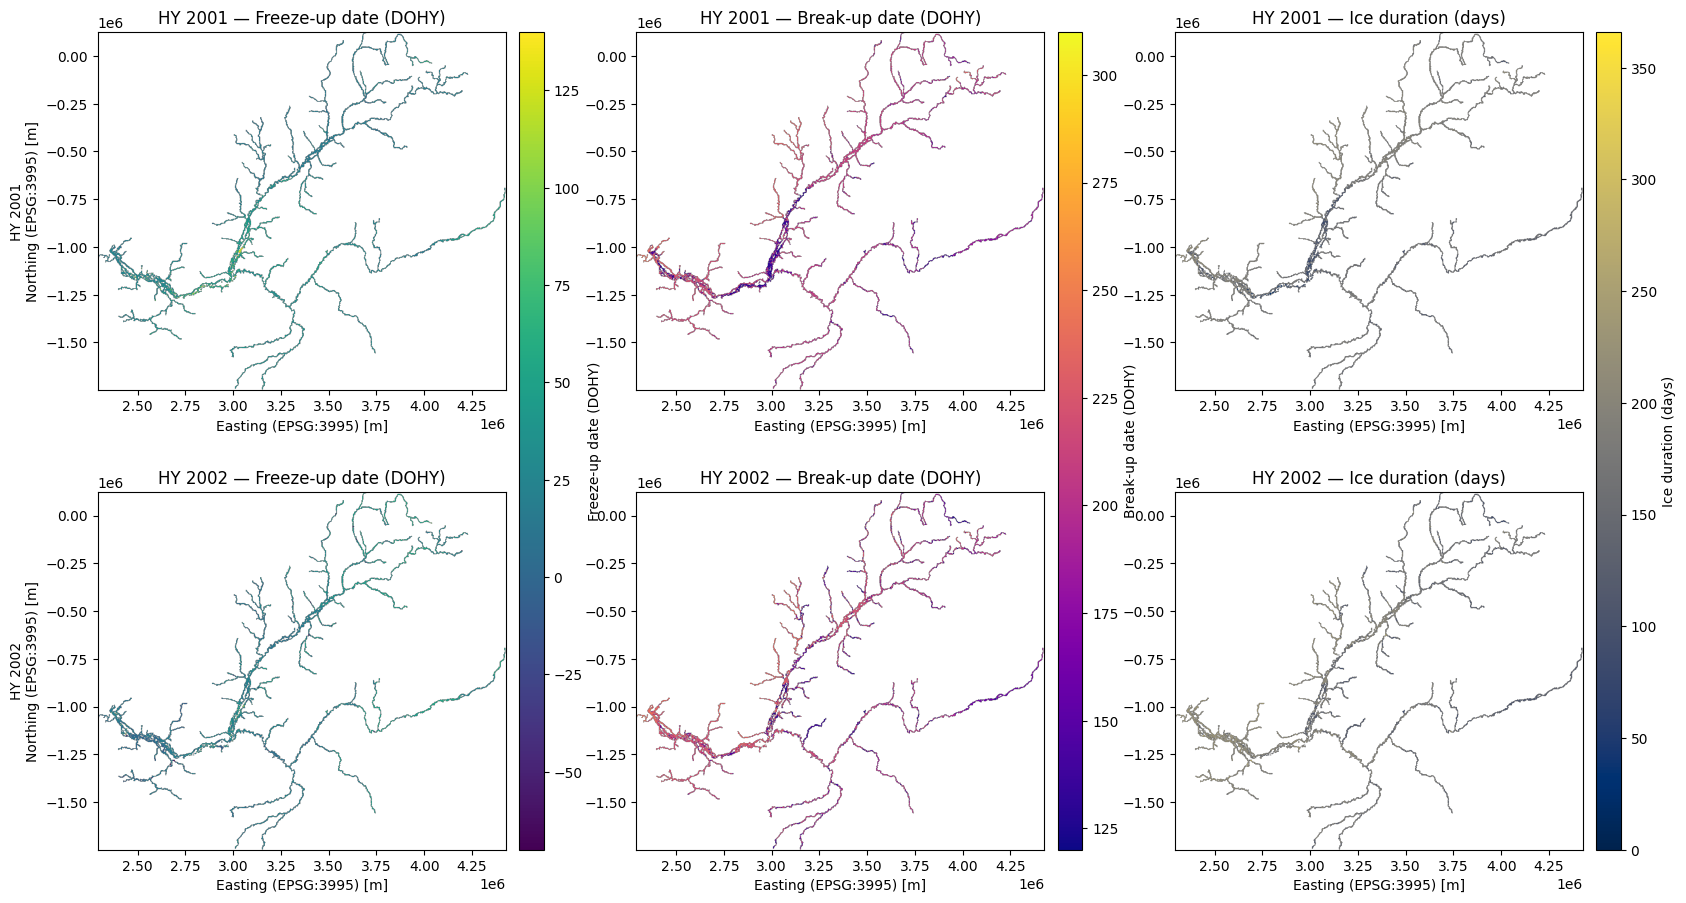

In [7]:
VISUALIZATION_CRS = "EPSG:3995"
YEARS_TO_PLOT = None  # Example: [2001, 2002]


def extract_year_from_filename(path_like):
    path_like = Path(path_like)
    match = re.search(r"(\d{4})", path_like.stem)
    return int(match.group(1)) if match else None


def collect_phenology_files():
    collected = {}

    for fp in sorted(FREEZE_DIR.glob("freezeup_DOHY_*.tif")):
        year = extract_year_from_filename(fp)
        if year is not None:
            collected.setdefault(year, {})["freeze"] = fp

    for fp in sorted(BREAK_DIR.glob("breakup_DOHY_*.tif")):
        year = extract_year_from_filename(fp)
        if year is not None:
            collected.setdefault(year, {})["break"] = fp

    for fp in sorted(DURATION_DIR.glob("ice_duration_DAY_*.tif")):
        year = extract_year_from_filename(fp)
        if year is not None:
            collected.setdefault(year, {})["duration"] = fp

    return dict(sorted(collected.items()))


def read_reprojected_map(path, dst_crs=VISUALIZATION_CRS, resampling=Resampling.nearest):
    path = Path(path)
    with rasterio.open(path) as src:
        if src.crs is None:
            raise RuntimeError(f"Source raster has no CRS information: {path}")

        arr = src.read(1).astype(np.float32)
        src_nodata = src.nodata
        if src_nodata is not None:
            arr = np.where(arr == src_nodata, np.nan, arr)

        fill_value = np.float32(NODATA_FLOAT)
        src_prepared = np.where(np.isfinite(arr), arr, fill_value).astype(np.float32)

        src_crs = CRS.from_user_input(src.crs)
        dst_crs_obj = CRS.from_user_input(dst_crs)

        if src_crs == dst_crs_obj:
            bounds = src.bounds
            out = np.where(src_prepared == fill_value, np.nan, src_prepared)
            return out, src.transform, (bounds.left, bounds.bottom, bounds.right, bounds.top)

        dst_transform, dst_width, dst_height = calculate_default_transform(
            src_crs, dst_crs_obj, src.width, src.height, *src.bounds
        )
        dst = np.full((dst_height, dst_width), fill_value, dtype=np.float32)

        reproject(
            source=src_prepared,
            destination=dst,
            src_transform=src.transform,
            src_crs=src_crs,
            src_nodata=fill_value,
            dst_transform=dst_transform,
            dst_crs=dst_crs_obj,
            dst_nodata=fill_value,
            resampling=resampling,
        )

        dst = np.where(dst == fill_value, np.nan, dst)
        left, bottom, right, top = array_bounds(dst_height, dst_width, dst_transform)
        return dst, dst_transform, (left, bottom, right, top)


def add_column_colorbar(fig, axes_col, mappable, label, pad=0.008, width=0.015):
    """
    Add one colorbar for an entire column of subplots.
    The colorbar height is exactly the same as the total height of that column.
    """
    fig.canvas.draw()  # Ensure subplot positions are finalized

    boxes = [ax.get_position() for ax in axes_col if ax.get_visible()]
    if not boxes:
        return None

    x0 = max(b.x1 for b in boxes) + pad
    y0 = min(b.y0 for b in boxes)
    y1 = max(b.y1 for b in boxes)

    cax = fig.add_axes([x0, y0, width, y1 - y0])
    cb = fig.colorbar(mappable, cax=cax)
    cb.set_label(label)
    return cb


def plot_ice_phenology_maps(years_to_plot=YEARS_TO_PLOT, dst_crs=VISUALIZATION_CRS):
    files_by_year = collect_phenology_files()
    if not files_by_year:
        raise RuntimeError(
            "No annual ice phenology outputs were found. Run the workflow cell first."
        )

    available_years = list(files_by_year.keys())
    if years_to_plot is None:
        years = available_years
    else:
        years = [y for y in years_to_plot if y in files_by_year]
        if not years:
            raise RuntimeError(
                f"None of the requested years were found in the output directory. Available years: {available_years}"
            )

    map_specs = [
        ("freeze", "Freeze-up date (DOHY)", FREEZE_RANGE, "viridis"),
        ("break", "Break-up date (DOHY)", BREAK_RANGE, "plasma"),
        ("duration", "Ice duration (days)", (0, 366), "cividis"),
    ]

    n_rows = len(years)
    n_cols = len(map_specs)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.5 * n_cols, 4.6 * n_rows),
        squeeze=False,
        constrained_layout=False,
    )

    column_images = [None] * n_cols

    for row_idx, year in enumerate(years):
        for col_idx, (key, title, value_range, cmap) in enumerate(map_specs):
            ax = axes[row_idx, col_idx]
            fp = files_by_year[year].get(key)

            if fp is None:
                ax.set_axis_off()
                ax.set_title(f"HY {year} — missing {key}")
                continue

            arr, transform, bounds = read_reprojected_map(fp, dst_crs=dst_crs)
            masked = np.ma.masked_invalid(arr)

            image = ax.imshow(
                masked,
                extent=(bounds[0], bounds[2], bounds[1], bounds[3]),
                origin="upper",
                cmap=cmap,
                vmin=value_range[0],
                vmax=value_range[1],
            )

            if column_images[col_idx] is None:
                column_images[col_idx] = image

            ax.set_title(f"HY {year} — {title}")
            ax.set_xlabel(f"Easting ({dst_crs}) [m]")

            if col_idx == 0:
                ax.set_ylabel(f"HY {year}\nNorthing ({dst_crs}) [m]")
            else:
                ax.set_ylabel("")

        print(f"Rendered annual phenology maps for hydrological year {year} in {dst_crs}.")

    # Reserve enough space between columns and around the figure
    # so each column-level colorbar can fit without overlap.
    fig.subplots_adjust(
        left=0.06,
        right=0.96,
        bottom=0.06,
        top=0.95,
        wspace=0.32,
        hspace=0.28,
    )

    # Add one colorbar per column, with height exactly matching the full column height
    for col_idx, (_, title, _, _) in enumerate(map_specs):
        if column_images[col_idx] is not None:
            add_column_colorbar(
                fig=fig,
                axes_col=axes[:, col_idx],
                mappable=column_images[col_idx],
                label=title,
                pad=0.008,
                width=0.015,
            )

    plt.show()


plot_ice_phenology_maps(years_to_plot=YEARS_TO_PLOT, dst_crs=VISUALIZATION_CRS)